In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

# Works when opened from the repository root or this notebook's folder.
ROOT = Path("docs/assignments/2-NetDiffusion")
if not ROOT.exists():
    ROOT = Path(".")
DATA = ROOT / "nd_data"
SCRIPTS = ROOT / "scripts"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

real_files = sorted((DATA / "real_nprints").glob("*.nprint"))
generated_images = sorted((DATA / "generated_traffic_images").glob("*.png"))
assert real_files and generated_images, "Extract the assignment data into nd_data first."
print(f"{len(real_files)} real traces; {len(generated_images)} generated images")


def read_nprint(path, nrows):
    packets = pd.read_csv(path, nrows=nrows)
    # The saved CSV row index is not a packet-header field.
    return packets.loc[:, ~packets.columns.str.startswith("Unnamed:")]

200 real traces; 100 generated images



---

## **Part 1 — Exploring Different Modalities / Representations of Network Traffic**

Synthetic network traffic generation is useful for many applications such as dataset augmentation, network testing, and resource management. Many existing generation methods treat traffic generation as either a time-series prediction task or an autoregressive modeling task. In these approaches, models are trained directly on structured representations of packets—one common example is **nPrint**, a tabular format that encodes packet header fields from PCAP traces into machine-learning-friendly numerical vectors.

In an **nPrint**, each row represents one packet in a trace. The entire nPrint file (a large CSV) represents all packets of that trace in sequential order. Header fields are encoded using one-hot–like binary indicators (e.g., `1`, `0`, or `01`), making them easy to feed into ML models.

However, general-purpose ML models—even advanced time-series architectures and transformers—often struggle to capture the *complex dependencies* present in real network traffic:

* **Local dependencies**: relationships among columns within a single row (i.e., dependencies among header fields of a single packet).
* **Global dependencies**: relationships across rows (i.e., the evolution of packets within the same flow).
  For example: if the first packet of a flow uses TCP, the second packet in that same flow should also be TCP; sequence numbers, flags, and flow identifiers evolve in structured ways over time.

While sequential ML models struggle with these multi-scale dependencies, **vision models** (e.g., diffusion models) excel at capturing both local and global structure when data is presented spatially—like an image. By converting nPrint traces into 2D PNG images, we can take advantage of the strong representational capabilities of image models and generate synthetic traffic using visual generative approaches.

---

### **Your Task for Part 1**

In this part of the assignment, you will:

1. **Inspect the raw nPrint files** (found in the `real_nprints` directory).
2. **Understand how each CSV row and column corresponds to packet-level metadata.**
3. **Follow the provided conversion pipeline** that transforms these nPrint CSVs into PNG image representations suitable for use with diffusion models and other visual architectures.
4. **Take an already generated set of image-representation of images and convert them back into nprint representation for downstream task utilization**

This will help you understand why converting network traces to images can unlock generative modeling capabilities that traditional ML approaches struggle with.

Q1:
First, download and unzip the data you will need from (https://drive.google.com/file/d/1hY6nNXEYOwl1l-O_nCknO9xezcHr6ZXi/view?usp=sharing)
In your own words, describe how an nPrint CSV encodes a network trace.
Why might a 2D image representation capture structural relationships that a row-by-row CSV cannot?

### Answer 1

An nPrint CSV stores packets in order, with one packet per row. Each column is a bit position in a header field, such as the IP version, TCP port, or TCP flag. 0 and 1 are bit values; -1 means that field is absent.

An image keeps packets as rows and fields as columns. A vision model can look across a packet and down consecutive packets to learn repeated fields, stripes, and changes over time.

In [2]:
example = read_nprint(real_files[0], nrows=1024)
print(real_files[0].name)
print(f"{len(example)} packets and {len(example.columns)} header-bit columns")
print("Values:", np.unique(example.to_numpy()))
display(example.iloc[:3, :12])

amazon_1024.nprint
1024 packets and 1088 header-bit columns
Values: [-1  0  1]


,ipv4_ver_0,ipv4_ver_1,ipv4_ver_2,ipv4_ver_3,ipv4_hl_0,ipv4_hl_1,ipv4_hl_2,ipv4_hl_3,ipv4_tos_0,ipv4_tos_1,ipv4_tos_2,ipv4_tos_3
0,0,1,0,0,0,1,0,1,0,0,0,0
1,0,1,0,0,0,1,0,1,0,0,0,0
2,0,1,0,0,0,1,0,1,0,0,0,0


Q2. Design a method for converting nPrint representations of traces (in the folder real_nprints) into image representations.
Your image representation should use only the first 1024 packets from each trace to avoid producing images that are too large.
Save the images into a folder called './nd_data/student_converted_images'

### Answer 2

I use one grayscale pixel per header bit: 0 → black, 1 → white, -1 → gray. Rows remain packets, and columns keep their original order. I keep max 1,024 packets and pad shorter traces with gray so every image has the same height.

In [ ]:
student_dir = DATA / "student_converted_images"
student_dir.mkdir(exist_ok=True)
shades = np.array([127, 0, 255], dtype=np.uint8)

for path in real_files:
    packets = read_nprint(path, nrows=1024)
    values = packets.to_numpy()
    assert list(packets.columns) == list(example.columns), path.name
    assert np.isin(values, [-1, 0, 1]).all(), path.name
    pixels = np.full((1024, len(packets.columns)), 127, dtype=np.uint8)
    pixels[:len(packets)] = shades[values.astype(int) + 1]
    Image.fromarray(pixels).save(student_dir / f"{path.stem}.png")

print(f"Saved {len(real_files)} grayscale images to {student_dir}")

Saved 200 grayscale images to nd_data/student_converted_images


In [4]:
result = subprocess.run(
    [sys.executable, str(SCRIPTS / "nprint_to_png.py"),
     "-i", str(DATA / "real_nprints"),
     "-o", str(DATA / "real_traffic_images")],
    check=True, capture_output=True, text=True,
)
print(result.stdout.strip())
assert len(list((DATA / "real_traffic_images").glob("*.png"))) == len(real_files)

Converted 200 nPrint files to nd_data/real_traffic_images


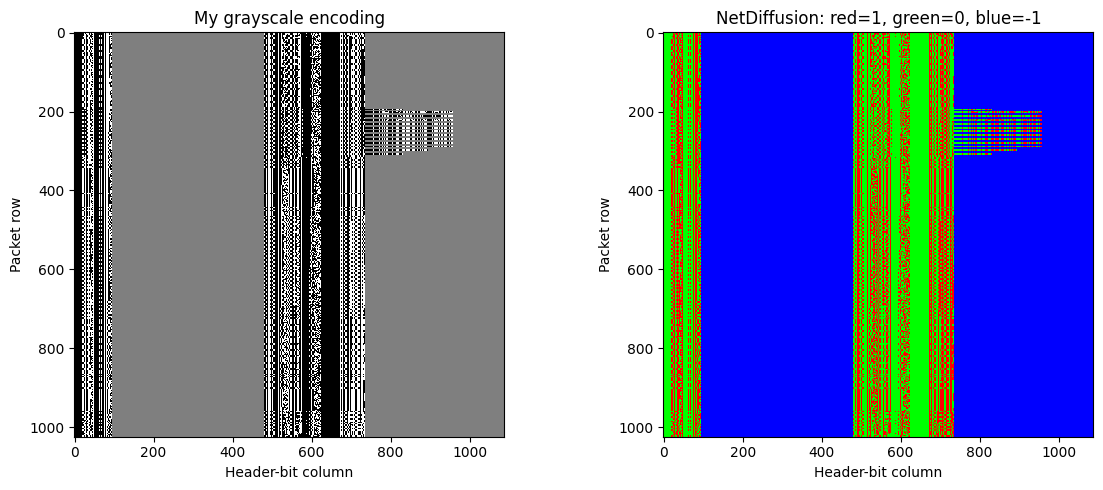

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, folder, title in zip(
    axes,
    [student_dir, DATA / "real_traffic_images"],
    ["My grayscale encoding", "NetDiffusion: red=1, green=0, blue=-1"],
):
    pixels = np.array(Image.open(folder / f"{real_files[0].stem}.png"))
    ax.imshow(pixels, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set(title=title, xlabel="Header-bit column", ylabel="Packet row")
plt.tight_layout()
plt.savefig(RESULTS / "encoding_comparison.png", dpi=150)
plt.show()

Q3: Now that you have seen how NetDiffusion converts nPrints into images, compare their method with the approach you designed in Q2. What are the advantages and disadvantages of each, especially in terms of what might help or hinder a vision model’s ability to learn?

### Answer 3

Both methods preserve the same packet/field layout and encode all three values distinctly.

My grayscale method: simple, uses one channel, and is easy to decode. However, gray lies between black and white, so a model could confuse an absent field with a blurred mixture of 0 and 1.

NetDiffusion: uses red for 1, green for 0, and blue for -1. The three colors are equally separated in RGB space and fit an RGB image model naturally. It needs more channels, and generated colors can drift away from the palette.

Both methods truncate long traces and use the absent-field color for padding, so neither records the original length of a short trace. The supplied converter also removes IP-address fields, which reduces address memorization but loses those identifiers.


---

## **Part 2 — Converting Generated Images Back Into Usable Format**

In the first part of the assignment, you explored how network traces in nPrint format can be transformed into image representations suitable for vision-based generative models. In Part 2, we focus on the reverse process: taking synthetic images produced by these models and converting them back into structured network representations.

This step is crucial because real-world applications do not operate on images—they require valid, interpretable packet traces that can be analyzed, replayed, or integrated into downstream tools.

---

### **Your Task for Part 2**

In this part of the assignment, you will:

1. **Convert generated images back into the original nPrint representation.**
   You will follow a scripted pipeline that translates pixel intensities and color channels back into binary header fields, reconstructing the packet-level structure of the trace.

2. **Apply essential post-processing techniques to correct errors introduced by diffusion models.**
   Generated images are rarely perfect—vision models may introduce color drift, pixel misalignment, noise, or structural artifacts.
   You will observe how heuristic correction, formatting enforcement, and reconstruction steps ensure that the converted nPrints become:

   * syntactically valid,
   * structurally consistent,
   * and replayable.

Across this section, your goal is to understand **why the reverse transformation is fragile**, which types of artifacts break reversibility, and how post-processing logic helps repair or compensate for generative errors.

For simplicity of this assignment, we have trainined and generated the images for you. If you have sufficient GPU access and want to try fine-tuning the model and generating the images yourself, feel free to take a look at the public repo (https://github.com/noise-lab/NetDiffusion).


Q4: We have taken the images converted by NetDiffusion and trained a LoRA-fine-tuned Stable Diffusion model (with ControlNet) to generate synthetic traffic images for you. These generated samples are stored in generated_traffic_images/.
Compare these generated images visually with the real images you saw earlier in real_traffic_images/.

Do you notice anything different between the real and generated traffic images? What immediately stands out as potentially problematic if we attempt to convert these generated images back into nPrint format? (Descriptive Only)

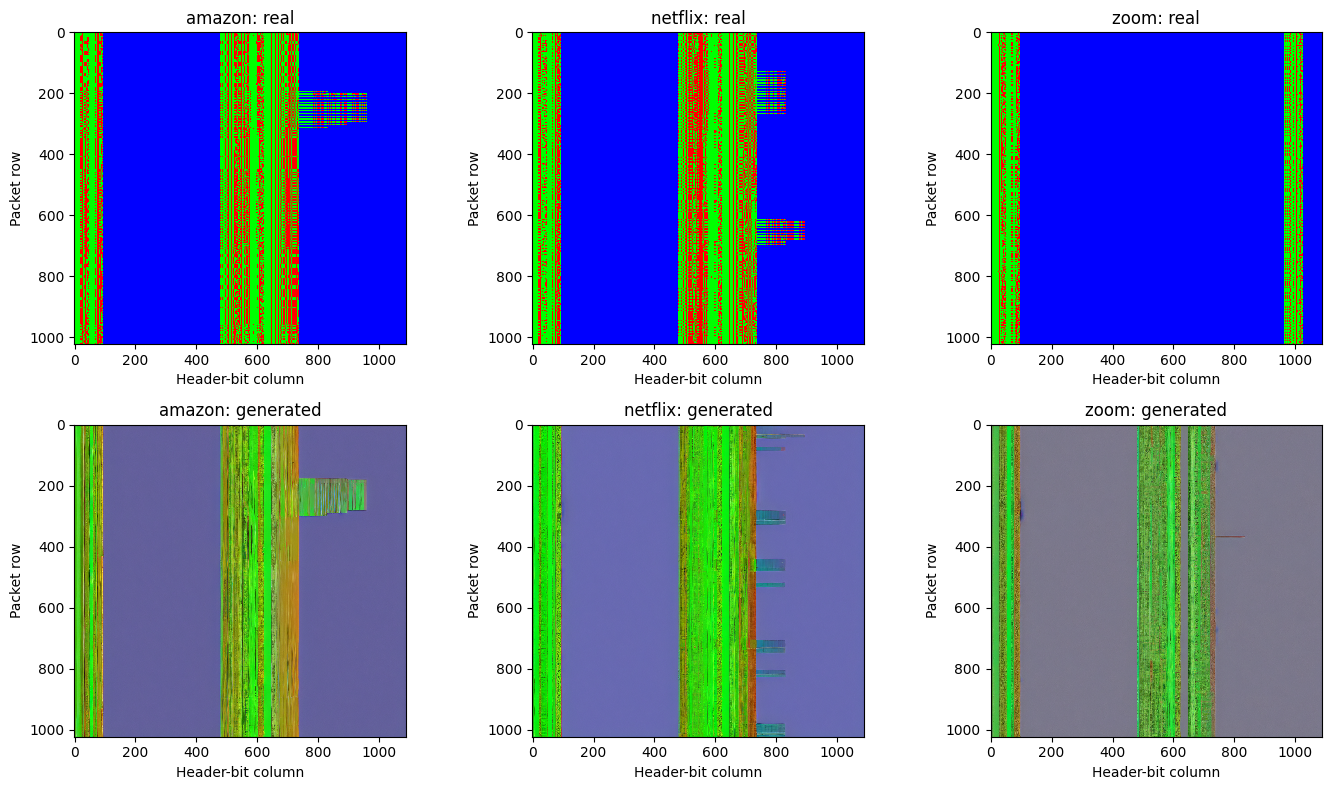

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for col, app in enumerate(["amazon", "netflix", "zoom"]):
    paths = [DATA / "real_traffic_images" / f"{app}_1024.png",
             DATA / "generated_traffic_images" / f"{app}_0.png"]
    for row, path in enumerate(paths):
        axes[row, col].imshow(Image.open(path), interpolation="nearest")
        axes[row, col].set_title(f"{app}: {'real' if row == 0 else 'generated'}")
        axes[row, col].set(xlabel="Header-bit column", ylabel="Packet row")
plt.tight_layout()
plt.savefig(RESULTS / "real_vs_generated.png", dpi=150)
plt.show()

### Answer 4

In these examples, the real images have sharp red/green details and solid blue areas for absent fields. The generated images keep broad vertical bands, but many colors become yellow, olive, or muted blue/purple. Fine bit patterns look smeared, and some boundaries shift or become uneven.

A generated pixel may therefore have no exact -1/0/1 interpretation. A shifted boundary can also put a value in the wrong header field or packet row. An image can look similar overall while encoding very different bits.

Q5: If you were to design a method to convert generated images back into nPrints, how would you do it? Explain your approach and describe how your method addresses the concerns you raised in Q4. (Descriptive only)

### Answer 5

I would check the image dimensions against the column template, then assign each pixel to the nearest allowed color: red → 1, green → 0, blue → -1.

Next, I'd restore the column names and check packet rules: valid IP versions and lengths, consistent protocols within a flow, and sensible TCP flags and sequence numbers. Before creating a PCAP, I'd also reconstruct required fields and recompute lengths. Color correction can fix small color drift but it cannot reliably recover a shifted field boundary or a missing packet.

Below are a set of pre-written scripts that perform the necessary post-generation augmentation and processing on the synthetic images you obtained from the diffusion model. These scripts handle tasks such as color normalization/augmentation and conversion from generated images back into nPrint format.
(The PCAP step is optional — you may run it if you are interested in observing or replaying the reconstructed traffic.)

In [ ]:
# Step 1: Run the supplied color correction unchanged.
result = subprocess.run(
    [sys.executable, str(SCRIPTS / "color_processor.py"),
     "--input_dir", str(DATA / "generated_traffic_images"),
     "--output_dir", str(DATA / "color_corrected_generated_traffic_images")],
    check=True, capture_output=True, text=True,
)
print(result.stdout.strip())
assert len(list((DATA / "color_corrected_generated_traffic_images").glob("*.png"))) == len(generated_images)

Processed 100 images.


In [8]:
# Step 2: Restore the original header-column names.
result = subprocess.run(
    [sys.executable, str(SCRIPTS / "image_to_nprint.py"),
     "--org_nprint", str(SCRIPTS / "column_example.nprint"),
     "--input_dir", str(DATA / "color_corrected_generated_traffic_images"),
     "--output_dir", str(DATA / "generated_nprint")],
    check=True, capture_output=True, text=True,
)
print(result.stdout.strip().splitlines()[-1])
assert len(list((DATA / "generated_nprint").glob("*.nprint"))) == len(generated_images)

Done! Converted 100 .png files into .nprint format.


Q6: You may now read through the provided scripts in color_processor.py (color augmentation / normalization) and image_to_nprint.py (image → nPrint reconstruction).
How do the post-processing methods implemented in these scripts compare to the approach you proposed in Q5?
Describe the pros and cons of both methods and highlight any differences in design philosophy, robustness, or assumptions.

### Answer 6

The supplied scripts also snap colors to red/green/blue and use a reference CSV to restore column names. They are simple and produce a usable table, but every pixel is forced into a category without a confidence score.

image_to_nprint.py maps exact colors back to numbers, assumes the image width matches the reference columns, and writes a saved row index that I remove when loading features. Neither script validates protocol rules, repairs shifted boundaries, or guarantees replayable traffic. My proposal adds uncertainty and protocol checks, at the cost of more code and possibly rejecting samples.

In [9]:
# Check every reconstructed table, including all 1,024 rows.
base_cols = read_nprint(SCRIPTS / "column_example.nprint", nrows=0).columns.tolist()
synthetic_files = sorted((DATA / "generated_nprint").glob("*.nprint"))
for path in synthetic_files:
    packets = read_nprint(path, nrows=None)
    assert packets.shape == (1024, len(base_cols)), path.name
    assert packets.columns.tolist() == base_cols, path.name
    assert np.isin(packets.to_numpy(), [-1, 0, 1]).all(), path.name
print(f"Checked {len(synthetic_files)} tables: matching columns, 1,024 rows, and only -1/0/1.")
print("These checks validate the table format, not network protocol correctness.")

Checked 100 tables: matching columns, 1,024 rows, and only -1/0/1.
These checks validate the table format, not network protocol correctness.



---

# **Part 3 — Using Real and Synthetic nPrints for Application Classification**

In the previous parts, you learned how network traces can be converted between nPrint and image representations, generated using diffusion models, and reconstructed back into nPrint format.
Now, you will evaluate how useful these generated nPrints are for downstream **machine learning tasks**.

Each nPrint file—whether real or generated—is labeled with the **application** that produced the traffic (e.g., `amazon_1.nprint` means this sample came from Amazon traffic).
In this section, you will treat each **entire nPrint file as a single sample** and build a simple ML pipeline to classify application labels.

To simplify the task, you will restrict your model to use **only the first 3 packets** (3 rows) from each nPrint.
This mimics “early packet classification,” where only the beginning of a flow is available.

---


Q7:

You now have access to both `real_nprints/` and `generated_nprint/`.
Notice that in both directories, files are labeled using the application associated with that nPrint (e.g., `amazon_1.nprint`).
Treat each **nPrint file** as one sample.

**Design an ML pipeline that trains a model using *synthetic nPrints* (from `generated_nprint/`) and evaluates its performance on *real nPrints* (from `real_nprints/`) to predict the correct application label.**

Your pipeline should:

1. Use only the **first 3 packets (first 3 rows)** of each nPrint file as input features.
2. Train a classifier on synthetic data from `generated_nprint/`.
3. Test the classifier on real data from `real_nprints/`.
4. Report how well the classifier performs.

The loader below reads the real and synthetic nPrints into DataFrames.

### Answer 7: Load three packets per file

I flatten the first three packet rows into one feature vector per file. Every file uses the same column order; a missing packet would be padded with -1. Filenames supply labels only, and saved CSV indices are removed. This replaces the longer starter loader with a short version that rejects unexpected values instead of silently turning them into zeros.

In [10]:
feature_cols = [f"pkt{packet}_{column}"
                for packet in range(1, 4) for column in base_cols]


def load_traces(files):
    rows = []
    labels = []
    for path in files:
        packets = read_nprint(path, nrows=3)
        assert not packets.empty and packets.columns.tolist() == base_cols, path.name
        assert np.isin(packets.to_numpy(), [-1, 0, 1]).all(), path.name
        packets = packets.reindex(range(3), fill_value=-1)
        rows.append(packets.to_numpy(dtype=np.int8).flatten())
        labels.append(path.stem.split("_")[0])
    frame = pd.DataFrame(rows, columns=feature_cols)
    frame["label"] = labels
    return frame


df_real = load_traces(real_files)
df_synth = load_traces(synthetic_files)
print(f"Features per trace: 3 packets × {len(base_cols)} fields = {len(feature_cols)}")
display(pd.DataFrame({"Real": df_real.label.value_counts(),
                      "Synthetic": df_synth.label.value_counts()}).sort_index())

Features per trace: 3 packets × 1088 fields = 3264


,Real,Synthetic
label,,
amazon,20,10
facebook,20,10
instagram,20,10
meet,20,10
netflix,20,10
teams,20,10
twitch,20,10
twitter,20,10
youtube,20,10


In [11]:
# Train on synthetic traces. Keep all real traces for testing.
X_train = df_synth[feature_cols]
y_train = df_synth["label"]
X_test = df_real[feature_cols]
y_test = df_real["label"]
assert set(y_train) == set(y_test), "Both sets must contain the same applications."

# Check for exact copies of the classifier input across training and testing.
train_rows = {row.tobytes() for row in X_train.to_numpy()}
test_rows = {row.tobytes() for row in X_test.to_numpy()}
print("Training traces (synthetic):", len(X_train))
print("Test traces (real):", len(X_test))
print("Identical three-packet feature vectors across sets:", len(train_rows & test_rows))

Training traces (synthetic): 100
Test traces (real): 200
Identical three-packet feature vectors across sets: 0


### Train on synthetic nPrints; test on real nPrints

I use a random forest with 100 trees and a fixed random seed. It can learn combinations of header bits without scaling. All 100 synthetic traces train the classifier, and all 200 real traces test it. I do not split packet rows or tune settings on the real test results.

Accuracy measures the fraction correct. Macro F1 gives each application equal weight. The majority-class baseline always predicts the most common synthetic training label.

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Learn application labels from synthetic traffic only.
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Evaluate on real traffic that was not used to fit this classifier.
predicted = model.predict(X_test)

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Compare with always predicting the most common training label.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

results = pd.DataFrame([{
    "Direction": "Synthetic to real",
    "Train samples": len(y_train),
    "Test samples": len(y_test),
    "Accuracy": accuracy_score(y_test, predicted),
    "Macro F1": f1_score(y_test, predicted, average="macro", zero_division=0),
    "Baseline accuracy": baseline.score(X_test, y_test),
}]).set_index("Direction")
display(results.round(3))
results.to_csv(RESULTS / "classification_results.csv")

# See which applications the model recognizes.
report = pd.DataFrame(classification_report(
    y_test, predicted, output_dict=True, zero_division=0,
)).T
display(report.round(3))
report.to_csv(RESULTS / "synthetic_to_real_report.csv")

,Train samples,Test samples,Accuracy,Macro F1,Baseline accuracy
Direction,,,,,
Synthetic to real,100,200,0.265,0.176,0.1


,precision,recall,f1-score,support
amazon,0.000,0.000,0.000,20.000
facebook,0.500,0.300,0.375,20.000
instagram,0.545,0.300,0.387,20.000
meet,0.500,0.100,0.167,20.000
netflix,0.500,0.050,0.091,20.000
teams,0.250,0.900,0.391,20.000
twitch,0.000,0.000,0.000,20.000
twitter,0.208,1.000,0.345,20.000
youtube,0.000,0.000,0.000,20.000
zoom,0.000,0.000,0.000,20.000


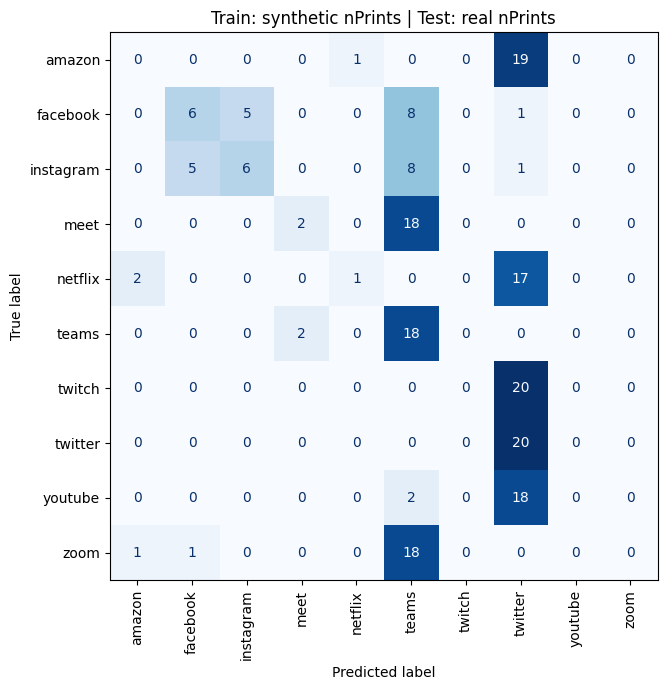

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, predicted, labels=sorted(y_test.unique()),
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90,
)
ax.set_title("Train: synthetic nPrints | Test: real nPrints")
plt.tight_layout()
plt.savefig(RESULTS / "synthetic_to_real_confusion_matrix.png", dpi=150)
plt.show()

### Interpretation

| Training → testing | Accuracy | Macro F1 | Majority baseline |
|---|---:|---:|---:|
| Synthetic → real | 26.5% | 0.176 | 10.0% |

The model correctly identifies 53 of 200 real traces, beating the 10% majority-class baseline. However, it has zero recall for four of the ten applications. The low F1 shows that useful patterns do not transfer evenly across applications. My personal thoughts are that this is impressive considering the fact that we are training only on synthetic data, but I think we either need more training samples for the diffusion model or we need to mix in some real data to get to acceptable levels of performance.